In [1]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Binary Classification") \
    .getOrCreate()

# Задание 1: Бинарная классификация (BinaryClassification)

## Задание 1.2: Сгенерировать подходящие исходные данные для проведения обучения

In [3]:
# Generate synthetic data for binary classification
def generate_synthetic_data(n_samples=1000, seed=42):
    np.random.seed(seed)

    # Generate two features
    X1 = np.random.normal(0, 1, n_samples)
    X2 = np.random.normal(0, 1, n_samples)

    # Generate binary labels with some noise
    # Class probability is based on linear combination of features
    prob = 1 / (1 + np.exp(-(2*X1 - X2 + 0.5)))
    y = (np.random.random(n_samples) < prob).astype(int)

    # Create pandas DataFrame
    df = pd.DataFrame({
        'feature1': X1,
        'feature2': X2,
        'label': y
    })

    return df

# Generate and display sample data
data_pd = generate_synthetic_data(n_samples=2000)
print(f"Data shape: {data_pd.shape}")
print(f"Class distribution: {data_pd['label'].value_counts()}")
data_pd.head()

Data shape: (2000, 3)
Class distribution: label
1    1198
0     802
Name: count, dtype: int64


,feature1,feature2,label
0,0.496714,-0.675178,1
1,-0.138264,-0.144519,1
2,0.647689,-0.792420,0
3,1.523030,-0.307962,1
4,-0.234153,-1.893615,1


In [4]:
# Convert pandas DataFrame to Spark DataFrame
data = spark.createDataFrame(data_pd)

# Split the data into training and test sets (70% training, 30% testing)
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)
print(f"Training data count: {train_data.count()}")
print(f"Test data count: {test_data.count()}")

Training data count: 1441
Test data count: 559


## Задание 1.2: Провести бинарную классификацию с помощью pyspark.ml

In [5]:
# Prepare features using VectorAssembler
feature_cols = ['feature1', 'feature2']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

# Transform the data to include the features vector
train_data = assembler.transform(train_data)
test_data = assembler.transform(test_data)

# Initialize the logistic regression model
lr = LogisticRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=10,
    regParam=0.1
)

# Train the model
lr_model = lr.fit(train_data)

# Print model coefficients
print(f"Coefficients: {lr_model.coefficients}")
print(f"Intercept: {lr_model.intercept}")

# Make predictions on test data
predictions = lr_model.transform(test_data)
predictions.select('label', 'prediction', 'probability').show(10)

Coefficients: [0.914408434151658,-0.3950801841881967]
Intercept: 0.3870887148658575
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.90509669032392...|
|    0|       0.0|[0.93411732845463...|
|    0|       0.0|[0.88089556009380...|
|    0|       0.0|[0.84433502041106...|
|    0|       0.0|[0.84784213455586...|
|    0|       0.0|[0.74549979408939...|
|    1|       0.0|[0.74709201317705...|
|    0|       0.0|[0.82927077892236...|
|    0|       0.0|[0.72930391170582...|
|    0|       0.0|[0.84060496638210...|
+-----+----------+--------------------+
only showing top 10 rows



## Задание 1.3: Провести расчет метрик

In [6]:
# Binary Classification Evaluator for AUC
evaluator_auc = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',
    labelCol='label',
    metricName='areaUnderROC'
)

# Multiclass Classification Evaluator for accuracy, precision, recall, f1
evaluator_acc = MulticlassClassificationEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='accuracy'
)

evaluator_prec = MulticlassClassificationEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='weightedPrecision'
)

evaluator_rec = MulticlassClassificationEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='weightedRecall'
)

evaluator_f1 = MulticlassClassificationEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='f1'
)

# Calculate metrics
auc = evaluator_auc.evaluate(predictions)
accuracy = evaluator_acc.evaluate(predictions)
precision = evaluator_prec.evaluate(predictions)
recall = evaluator_rec.evaluate(predictions)
f1 = evaluator_f1.evaluate(predictions)

# Print metrics
print(f"Area under ROC: {auc}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Create a dictionary of metrics
metrics = {
    'AUC': auc,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1
}

Area under ROC: 0.896206849501979
Accuracy: 0.8085867620751341
Precision: 0.806883616783236
Recall: 0.8085867620751341
F1 Score: 0.8050295852407763


## Задание 1.4: Сохранить полученные значения метрик в файл

In [7]:
# Convert metrics to DataFrame for saving
metrics_df = pd.DataFrame([metrics])
print("Metrics DataFrame:")
print(metrics_df)

# Save metrics to CSV file
metrics_file = "binary_classification_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)
print(f"Metrics saved to {metrics_file}")

# Also save metrics in Spark format
spark_metrics_df = spark.createDataFrame(metrics_df)
spark_metrics_df.write.csv("spark_metrics", header=True, mode="overwrite")
print("Metrics also saved in Spark CSV format")

Metrics DataFrame:
        AUC  Accuracy  Precision    Recall       F1
0  0.896207  0.808587   0.806884  0.808587  0.80503
Metrics saved to binary_classification_metrics.csv
Metrics also saved in Spark CSV format


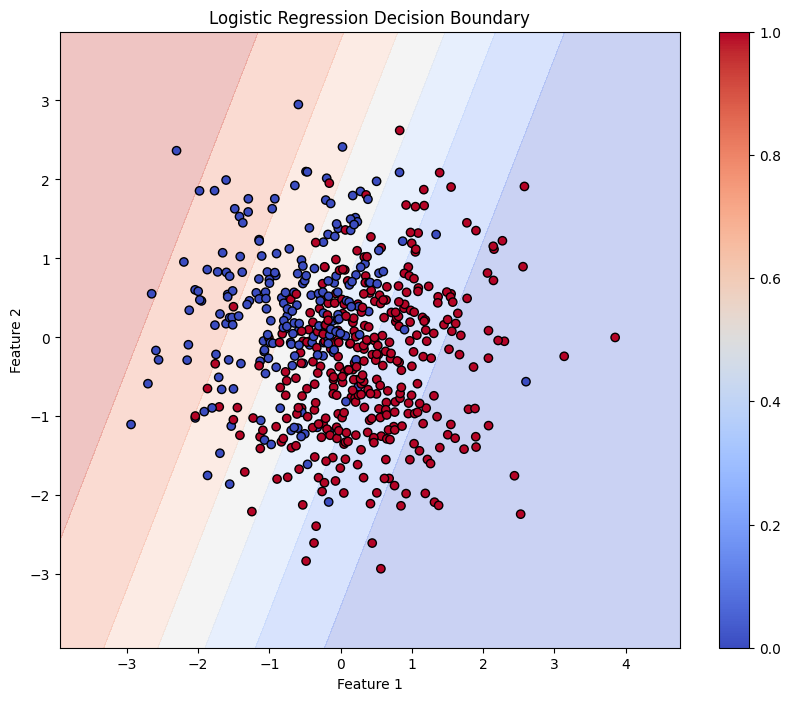

In [8]:
# Optional: Visualize the decision boundary

# Get model parameters
w1, w2 = lr_model.coefficients
b = lr_model.intercept

# Extract data for plotting
test_pd = test_data.select('feature1', 'feature2', 'label').toPandas()

# Create a meshgrid
x_min, x_max = test_pd['feature1'].min() - 1, test_pd['feature1'].max() + 1
y_min, y_max = test_pd['feature2'].min() - 1, test_pd['feature2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Calculate Z values for contour
Z = -(w1 * xx + w2 * yy + b)
Z = 1/(1 + np.exp(-Z))

# Plot decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(test_pd['feature1'], test_pd['feature2'], c=test_pd['label'],
            cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.colorbar()
plt.show()

# Stop Spark session
spark.stop()

# Задание 2. Кластеризация (KMeans)

In [9]:
# Import necessary libraries for K-means clustering
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import ClusteringEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

In [10]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("KMeans Clustering") \
    .getOrCreate()

## Задание 2.1: Сгенерировать подходящие исходные данные для проведения обучения

Data shape: (986, 3)
True cluster centers: [(3.745401188473625, 9.50714306409916), (7.319939418114051, 5.986584841970366), (1.5601864044243652, 1.5599452033620265)]


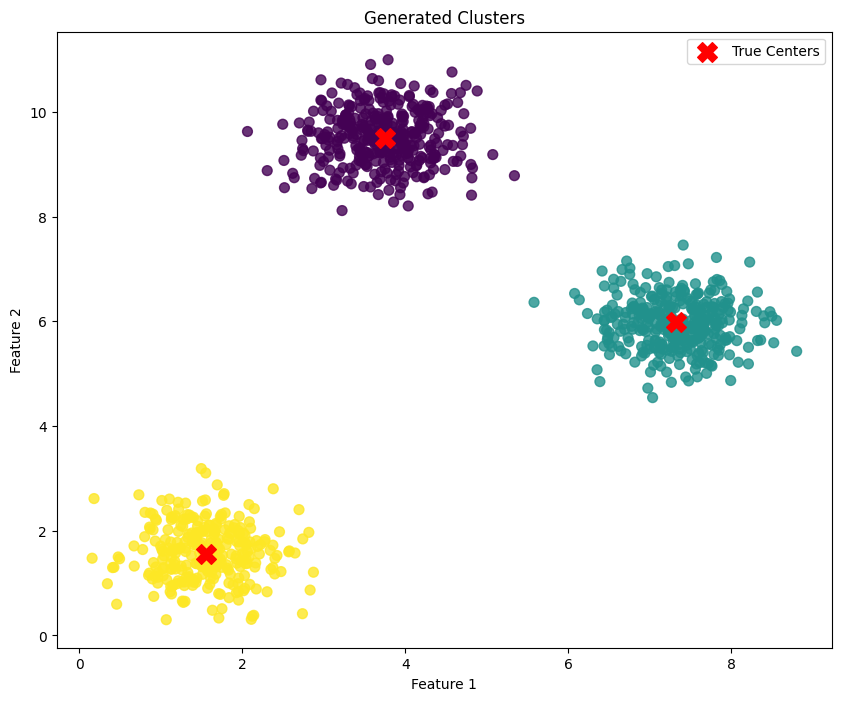

In [11]:
def generate_cluster_data(n_samples=1000, n_centers=3, seed=42):
    """Generate synthetic data for clustering with well-defined clusters"""
    np.random.seed(seed)

    # Create centers for clusters
    centers = []
    for i in range(n_centers):
        centers.append((np.random.rand() * 10, np.random.rand() * 10))

    # Generate data points around centers
    X = []
    y = []  # True cluster labels (for evaluation only)

    for i, (cx, cy) in enumerate(centers):
        # Generate random number of points for this cluster
        n_points = n_samples // n_centers + np.random.randint(-50, 50)

        # Generate points with normal distribution around center
        cluster_x = np.random.normal(cx, 0.5, n_points)
        cluster_y = np.random.normal(cy, 0.5, n_points)

        # Add to data
        for j in range(n_points):
            X.append([cluster_x[j], cluster_y[j]])
            y.append(i)

    # Create pandas DataFrame
    df = pd.DataFrame(X, columns=['feature1', 'feature2'])
    df['true_label'] = y  # Keep true labels for evaluation

    return df, centers

# Generate and display sample data
data_pd, true_centers = generate_cluster_data(n_samples=1000, n_centers=3)
print(f"Data shape: {data_pd.shape}")
print(f"True cluster centers: {true_centers}")

# Plot the data
plt.figure(figsize=(10, 8))
plt.scatter(data_pd['feature1'], data_pd['feature2'], c=data_pd['true_label'],
            cmap='viridis', s=50, alpha=0.8)
plt.scatter([c[0] for c in true_centers], [c[1] for c in true_centers],
            c='red', marker='X', s=200, label='True Centers')
plt.title('Generated Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# Convert pandas DataFrame to Spark DataFrame
data = spark.createDataFrame(data_pd)

## Задание 2.2: Провести кластеризацию с помощью pyspark.ml

In [12]:
# Prepare features using VectorAssembler
feature_cols = ['feature1', 'feature2']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
data = assembler.transform(data)

# Create and train a K-means model
k = 3  # Number of clusters
kmeans = KMeans(featuresCol='features', k=k, seed=42, maxIter=20)
model = kmeans.fit(data)

# Get predictions
predictions = model.transform(data)

# Evaluate clustering using Silhouette score
evaluator = ClusteringEvaluator(
    predictionCol='prediction',
    featuresCol='features',
    metricName='silhouette'
)
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette score: {silhouette}")

# Get cluster centers
centers = model.clusterCenters()
print("Cluster Centers:")
for i, center in enumerate(centers):
    print(f"Center {i}: {center}")

Silhouette score: 0.9647797495587742
Cluster Centers:
Center 0: [7.31914188 5.95930569]
Center 1: [1.5544698  1.59842086]
Center 2: [3.7327719  9.51504406]


# Задание 2.3: Вывести и сохранить в файл полученные центры кластеров

In [13]:
# Convert cluster centers to DataFrame
center_rows = []
for i, center in enumerate(centers):
    center_rows.append((i, float(center[0]), float(center[1])))

centers_df = spark.createDataFrame(center_rows, ["cluster", "feature1", "feature2"])
centers_df.show()

# Save cluster centers to CSV file
centers_pd = centers_df.toPandas()
centers_file = "kmeans_cluster_centers.csv"
centers_pd.to_csv(centers_file, index=False)
print(f"Cluster centers saved to {centers_file}")

# Also save in Spark format
centers_df.write.csv("spark_centers", header=True, mode="overwrite")
print("Centers also saved in Spark CSV format")

+-------+------------------+------------------+
|cluster|          feature1|          feature2|
+-------+------------------+------------------+
|      0| 7.319141876571306| 5.959305693408726|
|      1|1.5544698042770815|1.5984208606522337|
|      2|3.7327719006251625| 9.515044055261974|
+-------+------------------+------------------+

Cluster centers saved to kmeans_cluster_centers.csv
Centers also saved in Spark CSV format


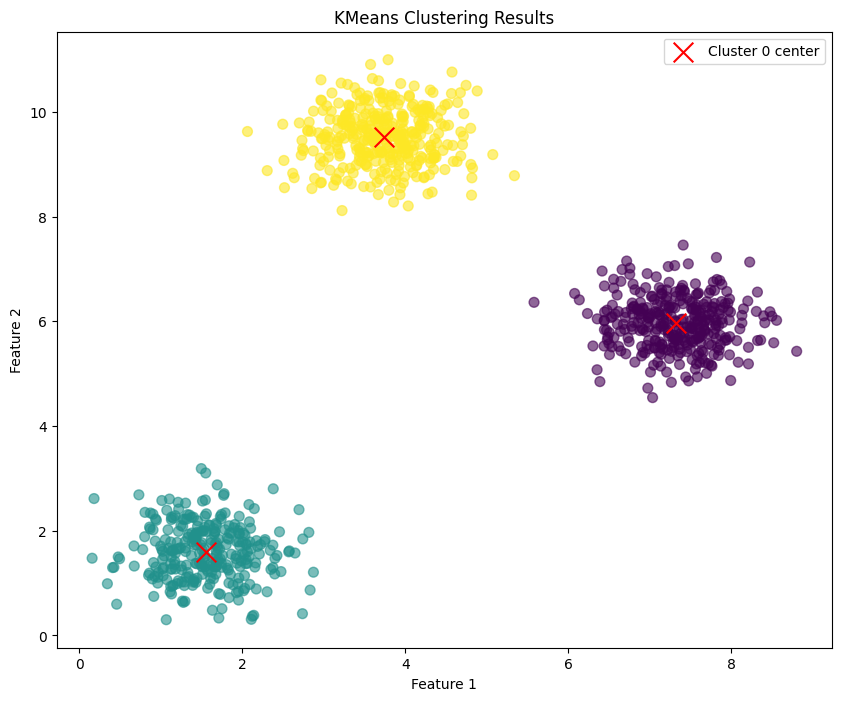

In [14]:
# Visualize the clustering results
# Get cluster predictions and convert to pandas for plotting
plot_data = predictions.select('feature1', 'feature2', 'prediction').toPandas()

plt.figure(figsize=(10, 8))
plt.scatter(plot_data['feature1'], plot_data['feature2'],
            c=plot_data['prediction'], cmap='viridis', s=50, alpha=0.6)

# Plot the learned centers
for i, center in enumerate(centers):
    plt.scatter(center[0], center[1], c='red', marker='x', s=200,
                label=f'Cluster {i} center' if i == 0 else "")

plt.title('KMeans Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# Stop Spark session
spark.stop()

# Задание 3. Регрессия (LinearRegression)

In [15]:
# Import necessary libraries for linear regression
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Linear Regression") \
    .getOrCreate()

# Задание 3.1: Сгенерировать подходящие исходные данные для проведения обучения

In [17]:
def generate_regression_data(n_samples=1000, n_features=3, noise=0.5, seed=42):
    """Generate synthetic data for regression with linear relationship"""
    np.random.seed(seed)

    # Generate feature matrix X
    X = np.random.randn(n_samples, n_features)

    # Generate true coefficients
    true_coef = np.array([2.5, -1.3, 0.7])  # Example coefficients

    # Generate target values with noise
    y = X.dot(true_coef) + 0.3  # Add intercept
    y += np.random.normal(0, noise, size=n_samples)  # Add noise

    # Create pandas DataFrame
    columns = [f'feature{i+1}' for i in range(n_features)]
    df = pd.DataFrame(X, columns=columns)
    df['label'] = y

    return df, true_coef

# Generate and display sample data
n_features = 3
data_pd, true_coef = generate_regression_data(n_samples=1000, n_features=n_features)
print(f"Data shape: {data_pd.shape}")
print(f"True coefficients: {true_coef}")
data_pd.head()

# Convert pandas DataFrame to Spark DataFrame
data = spark.createDataFrame(data_pd)

# Split the data into training and test sets (70% training, 30% testing)
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)
print(f"Training data count: {train_data.count()}")
print(f"Test data count: {test_data.count()}")

Data shape: (1000, 4)
True coefficients: [ 2.5 -1.3  0.7]
Training data count: 712
Test data count: 288


# Задание 3.2: Провести регрессию с помощью pyspark.ml

In [18]:
# Prepare features using VectorAssembler
feature_cols = [f'feature{i+1}' for i in range(n_features)]
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

# Transform the data to include the features vector
train_data = assembler.transform(train_data)
test_data = assembler.transform(test_data)

# Initialize the linear regression model
lr = LinearRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=10,
    regParam=0.1,
    elasticNetParam=0.0  # 0.0 for L2 regularization (Ridge), 1.0 for L1 (Lasso)
)

# Train the model
lr_model = lr.fit(train_data)

# Print model coefficients
print(f"Coefficients: {lr_model.coefficients}")
print(f"Intercept: {lr_model.intercept}")
print(f"True coefficients: {true_coef}")
print(f"True intercept: 0.3")

# Make predictions on test data
predictions = lr_model.transform(test_data)
predictions.select('label', 'prediction').show(10)

Coefficients: [2.4322335853313093,-1.2748896180660658,0.6628450889436939]
Intercept: 0.3054737220134505
True coefficients: [ 2.5 -1.3  0.7]
True intercept: 0.3
+-------------------+-------------------+
|              label|         prediction|
+-------------------+-------------------+
| -5.895734677250211| -5.936290004472058|
| -5.294985267732606| -5.320346581895568|
| -5.072049332811614| -4.684891044679921|
| -4.287485501916329|-3.8153625656715318|
| -5.438435685146175| -5.865738174541618|
|-4.8663088307074265| -4.454202867523321|
|-3.6791462150144403| -4.144422288241411|
| -5.134050311783155| -5.380730633149669|
| -2.571835524225289|-2.2420715628173067|
| -2.539983239842659|-2.5252952720774537|
+-------------------+-------------------+
only showing top 10 rows



# Задание 3.3: Провести расчет метрик

In [19]:
# Create evaluators for different metrics
evaluator_rmse = RegressionEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='rmse'
)

evaluator_r2 = RegressionEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='r2'
)

evaluator_mae = RegressionEvaluator(
    predictionCol='prediction',
    labelCol='label',
    metricName='mae'
)

# Calculate metrics
rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

# Print metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")

# Create a dictionary of metrics
metrics = {
    'RMSE': rmse,
    'R2': r2,
    'MAE': mae
}

Root Mean Squared Error (RMSE): 0.5084383504917819
R² Score: 0.9701870932416616
Mean Absolute Error (MAE): 0.4029752289204696


# Задание 3.4: Сохранить полученные значения метрик в файл


In [20]:
# Convert metrics to DataFrame for saving
metrics_df = pd.DataFrame([metrics])
print("Metrics DataFrame:")
print(metrics_df)

# Save metrics to CSV file
metrics_file = "linear_regression_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)
print(f"Metrics saved to {metrics_file}")

# Also save metrics in Spark format
spark_metrics_df = spark.createDataFrame(metrics_df)
spark_metrics_df.write.csv("spark_regression_metrics", header=True, mode="overwrite")
print("Metrics also saved in Spark CSV format")

Metrics DataFrame:
       RMSE        R2       MAE
0  0.508438  0.970187  0.402975
Metrics saved to linear_regression_metrics.csv
Metrics also saved in Spark CSV format


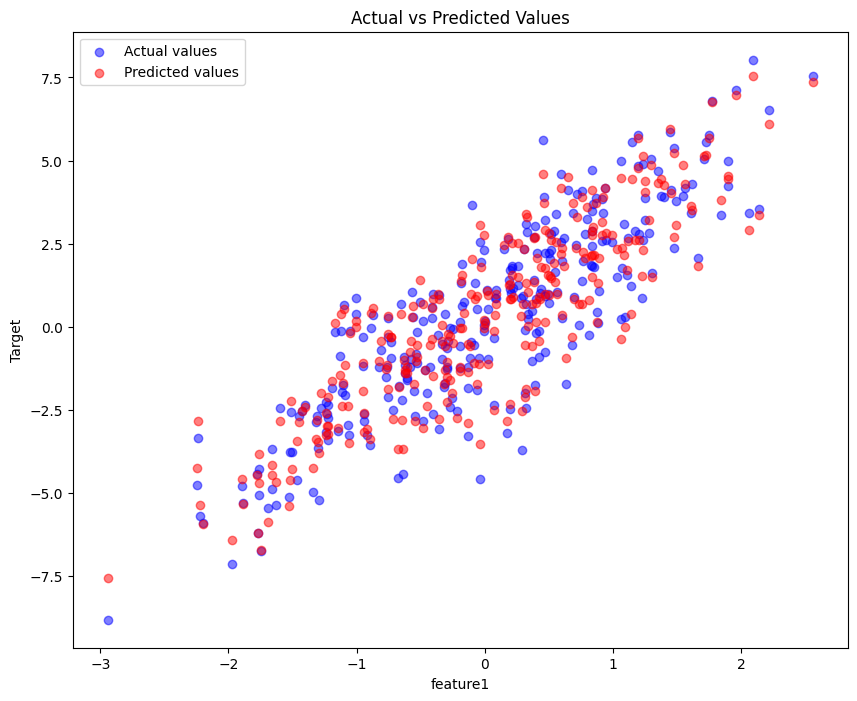

In [21]:
# Visualize the results for one feature
# Get one feature to plot actual vs. predicted
feature_to_plot = 'feature1'

# Extract data for plotting
plot_data = predictions.select(feature_to_plot, 'label', 'prediction').toPandas()

plt.figure(figsize=(10, 8))
plt.scatter(plot_data[feature_to_plot], plot_data['label'],
            color='blue', label='Actual values', alpha=0.5)
plt.scatter(plot_data[feature_to_plot], plot_data['prediction'],
            color='red', label='Predicted values', alpha=0.5)
plt.xlabel(feature_to_plot)
plt.ylabel('Target')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Stop Spark session
spark.stop()

# Задание 4

In [35]:
# Import necessary libraries for Word2Vec
from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec
from pyspark.sql.types import ArrayType, StringType
from pyspark.sql.functions import udf, col, explode
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os
import random

In [36]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Word2Vec Example") \
    .getOrCreate()

# Задание 4.1: Сгенерировать подходящие исходные данные для проведения обучения

In [37]:
def generate_text_data():
    """
    Generate synthetic text data with semantic relationships
    for training Word2Vec embeddings
    """
    # Categories for creating related terms
    categories = {
        "countries": ["russia", "france", "germany", "italy", "spain", "china", "japan", "usa", "canada", "brazil"],
        "capitals": ["moscow", "paris", "berlin", "rome", "madrid", "beijing", "tokyo", "washington", "ottawa", "brasilia"],
        "animals": ["dog", "cat", "horse", "elephant", "tiger", "lion", "bear", "wolf", "fox", "deer"],
        "food": ["pizza", "burger", "sushi", "pasta", "taco", "salad", "steak", "rice", "bread", "cheese"],
        "professions": ["doctor", "engineer", "teacher", "artist", "programmer", "scientist", "chef", "driver", "writer", "musician"],
        "colors": ["red", "blue", "green", "yellow", "black", "white", "purple", "orange", "pink", "brown"],
        "transport": ["car", "bus", "train", "plane", "ship", "bicycle", "motorcycle", "truck", "helicopter", "subway"],
        "family": ["mother", "father", "sister", "brother", "son", "daughter", "husband", "wife", "uncle", "aunt"]
    }

    # Template sentences to create patterns
    templates = [
        "The COUNTRY capital is CAPITAL.",
        "ANIMAL is a type of animal that lives in the COUNTRY.",
        "A PROFESSION in COUNTRY often eats FOOD.",
        "The COLOR TRANSPORT traveled from CAPITAL to another city.",
        "My FAMILY likes to eat FOOD from COUNTRY.",
        "The PROFESSION used a COLOR TRANSPORT to get to work.",
        "In CAPITAL, many people enjoy FOOD with their FAMILY.",
        "The ANIMAL has COLOR fur and is common in COUNTRY.",
        "A FAMILY member who works as a PROFESSION often wears COLOR clothing.",
        "People in COUNTRY use TRANSPORT to visit CAPITAL.",
        "The PROFESSION studied the ANIMAL found in COUNTRY.",
        "CAPITAL is known for its COLOR buildings and delicious FOOD.",
        "My FAMILY saw a COLOR ANIMAL while visiting COUNTRY.",
        "The TRANSPORT stopped in CAPITAL to pick up the PROFESSION.",
        "A PROFESSION from COUNTRY invented a new type of FOOD."
    ]

    # Create 1000 sentences
    sentences = []
    for _ in range(1000):
        template = random.choice(templates)

        # Replace placeholders with random words from categories
        for category in categories:
            placeholder = category.upper()
            if placeholder in template:
                word = random.choice(categories[category])
                template = template.replace(placeholder, word)

        sentences.append(template)

    # Add additional sentences with specific semantic relationships
    # These help to create analogies like "king is to queen as man is to woman"
    relationship_pairs = [
        ("man", "woman", "king", "queen"),
        ("father", "mother", "son", "daughter"),
        ("brother", "sister", "uncle", "aunt"),
        ("france", "paris", "japan", "tokyo"),
        ("russia", "moscow", "germany", "berlin"),
        ("dog", "puppy", "cat", "kitten"),
    ]

    for a, b, c, d in relationship_pairs:
        sentences.extend([
            f"{a} relates to {b} as {c} relates to {d}.",
            f"The relationship between {a} and {b} is like {c} and {d}.",
            f"{a} is to {b} what {c} is to {d}.",
            f"If {a} then {b}, if {c} then {d}."
        ])

    # Tokenize sentences
    tokenized_sentences = [sentence.lower().replace(".", "").replace(",", "").split() for sentence in sentences]

    return tokenized_sentences

# Generate the data
documents = generate_text_data()

# Preview a few generated sentences
print("Sample documents:")
for doc in documents[:5]:
    print(doc)

# Convert to DataFrame with a documents column containing token arrays
documentDF = spark.createDataFrame([(doc,) for doc in documents], ["words"])
print("Document DataFrame schema:")
documentDF.printSchema()
documentDF.show(5)

Sample documents:
['the', 'train', 'stopped', 'in', 'capital', 'to', 'pick', 'up', 'the', 'profession']
['the', 'plane', 'stopped', 'in', 'capital', 'to', 'pick', 'up', 'the', 'profession']
['the', 'color', 'train', 'traveled', 'from', 'capital', 'to', 'another', 'city']
['my', 'brother', 'saw', 'a', 'color', 'animal', 'while', 'visiting', 'country']
['the', 'color', 'ship', 'traveled', 'from', 'capital', 'to', 'another', 'city']
Document DataFrame schema:
root
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)

+--------------------+
|               words|
+--------------------+
|[the, train, stop...|
|[the, plane, stop...|
|[the, color, trai...|
|[my, brother, saw...|
|[the, color, ship...|
+--------------------+
only showing top 5 rows



# Задание 4.2: Провести векторизацию слов с помощью pyspark.ml

In [38]:
# Train the Word2Vec model
word2Vec = Word2Vec(
    vectorSize=100,        # Size of the word vectors
    minCount=5,            # Minimum number of times a word must appear
    windowSize=5,          # Context window size
    maxSentenceLength=100, # Maximum length of sentences
    numPartitions=1,       # For parallelism
    inputCol="words",
    outputCol="word_vectors"
)

# Fit the model
model = word2Vec.fit(documentDF)

# Get the vectors for all words in the vocabulary
word_vectors = model.getVectors()
print("Number of distinct words:", word_vectors.count())

# Display some of the word vectors
print("Word Vectors dataframe:")
word_vectors.show(10)

# Find synonyms for a few words
words_to_check = ["woman", "paris", "food", "doctor"]
print("Finding synonyms:")
for word in words_to_check:
    try:
        synonyms = model.findSynonyms(word, 5)
        print(f"\nSynonyms for '{word}':")
        synonyms.show()
    except:
        print(f"Word '{word}' not found in vocabulary")

Number of distinct words: 95
Word Vectors dataframe:
+---------+--------------------+
|     word|              vector|
+---------+--------------------+
|    salad|[-0.0035795739386...|
|     used|[-0.0110987033694...|
|buildings|[-0.0426298119127...|
|   mother|[-1.7912127077579...|
|      for|[0.04654517769813...|
| invented|[-0.2176035791635...|
|    works|[-0.2972345948219...|
|   people|[0.20543721318244...|
|     city|[0.26013192534446...|
|   cheese|[0.04168463125824...|
+---------+--------------------+
only showing top 10 rows

Finding synonyms:
Word 'woman' not found in vocabulary
Word 'paris' not found in vocabulary
Word 'food' not found in vocabulary
Word 'doctor' not found in vocabulary


# Задание 4.3: Сохранить полученные векторы

In [39]:
# Save model
model_path = "word2vec_model"
model.save(model_path)
print(f"Model saved to {model_path}")

# Save word vectors to CSV
vectors_df = word_vectors.toPandas()
vectors_file = "word_vectors.csv"
vectors_df.to_csv(vectors_file, index=False)
print(f"Word vectors saved to {vectors_file}")

# Save in Parquet format for more efficient storage of vector data
word_vectors.write.parquet("word_vectors_parquet", mode="overwrite")
print("Word vectors also saved in Parquet format")

Model saved to word2vec_model1
Word vectors saved to word_vectors.csv
Word vectors also saved in Parquet format


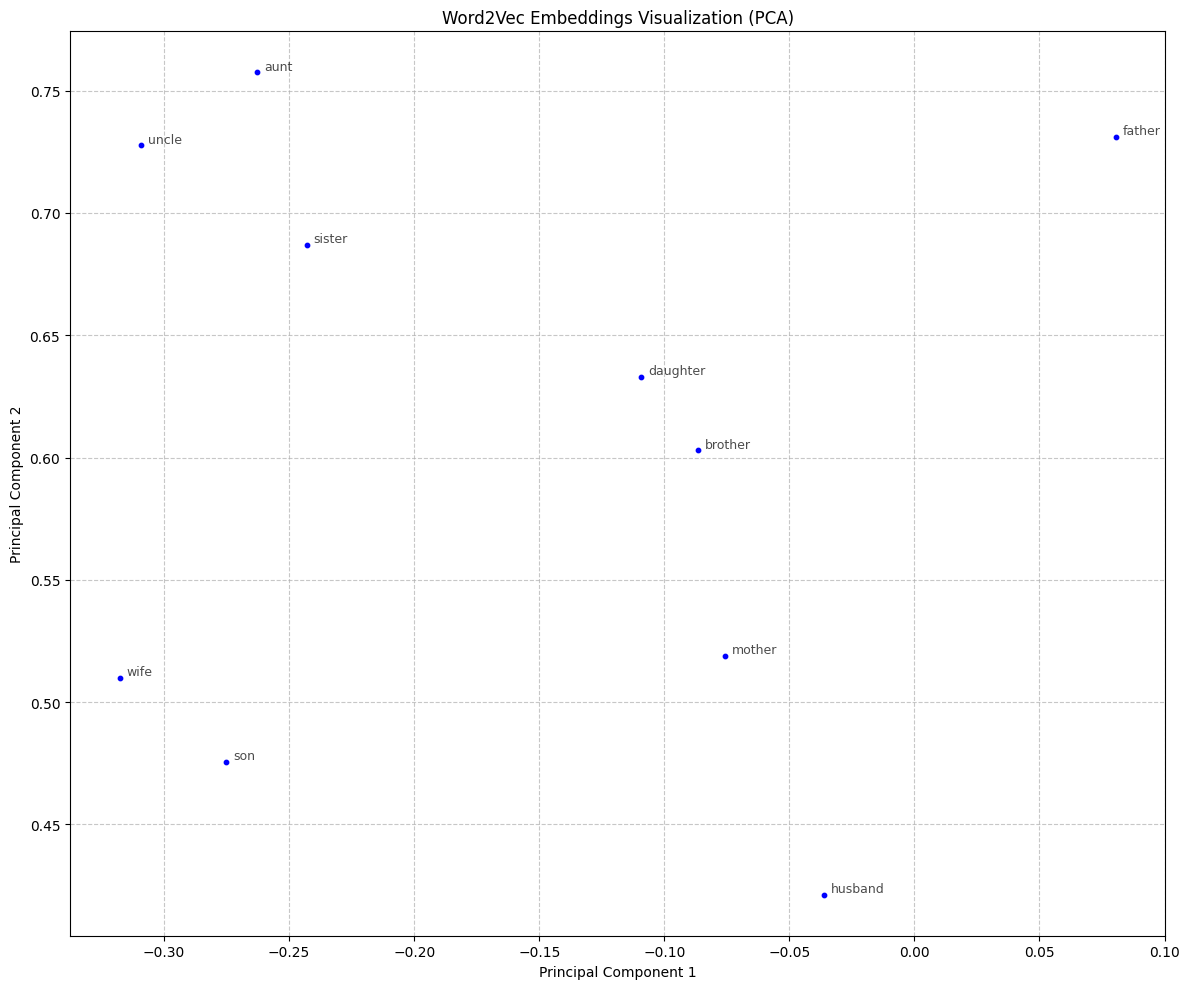

In [40]:
# Visualize some word vectors using PCA to reduce dimensions
# Convert to pandas for visualization
vectors_pd = word_vectors.select("word", "vector").toPandas()

# Extract words and vectors
words = vectors_pd["word"].tolist()
vectors = np.array(vectors_pd["vector"].tolist())

# Apply PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# Define categories of words to visualize
visualization_categories = {
    "countries": ["russia", "france", "germany", "italy", "spain", "china", "japan", "usa", "canada", "brazil"],
    "capitals": ["moscow", "paris", "berlin", "rome", "madrid", "beijing", "tokyo", "washington", "ottawa", "brasilia"],
    "family": ["mother", "father", "sister", "brother", "son", "daughter", "husband", "wife", "uncle", "aunt"],
    "professions": ["doctor", "engineer", "teacher", "artist", "programmer", "scientist", "chef", "driver", "writer", "musician"]
}

# Select words to plot
words_to_plot = []
for category in visualization_categories.values():
    words_to_plot.extend(category)

# Filter to only include words in our vocabulary
plot_indices = [i for i, word in enumerate(words) if word in words_to_plot]
plot_words = [words[i] for i in plot_indices]
plot_vectors = result[plot_indices]

# Plot the vectors
plt.figure(figsize=(12, 10))
plt.scatter(plot_vectors[:, 0], plot_vectors[:, 1], marker='o', s=10, color='blue')

# Add word labels
for i, word in enumerate(plot_words):
    plt.annotate(word, xy=(plot_vectors[i, 0], plot_vectors[i, 1]),
                 xytext=(5, 2), textcoords='offset points',
                 fontsize=9, alpha=0.7)

plt.title("Word2Vec Embeddings Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
# Stop Spark session
spark.stop()